## Solve an elliptic PDE: Chebyshev basis

In [7]:
import sys
import os
import math
import numpy as np
import scipy

import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib
%config InlineBackend.figure_format = 'retina'

import seaborn as sns

# SEABORN & MATPLOTLIBN CONFIGURATION
# seaborn styles (choose by changing index at end)
context=['paper', 'notebook', 'talk', 'poster'] [1]
palette=['deep', 'muted', 'bright', 'pastel', 'dark', 'colorblind', 'hls', 'tab10'] [2]
style=['darkgrid', 'whitegrid', 'dark', 'white', 'ticks'] [4] 

# extra customizations
# https://matplotlib.org/stable/tutorials/introductory/customizing.html
# uncomment this to get list of all rc-params: 
#print(plt.rcParams.keys())
rc={"axes.grid":"false", #"true",
    "axes.grid.which": "major",
    "grid.color":'lightgrey',
    "grid.linewidth":0.6,
    'xtick.direction':'in',
    'xtick.top':True,
    'ytick.direction':'in',
    'ytick.right':True
    }

sns.set_theme(style=style,context=context, palette=palette,
              font_scale=1, rc=rc)
print(sys.version)
print("Seaborn version {}".format(sns.__version__))

3.8.16 (default, Jun 12 2023, 18:09:05) 
[GCC 11.2.0]
Seaborn version 0.12.2


In [8]:
sys.path.append("../Final")
import Chebyshev

In [3]:
def ChebyshevInterpolate(u, ToSpec, x_out):
    """Interpolate the data u[i], assumed to be
    real-space values of a chebyshev expansion,
    to the grid-points in x_out.
    ToSpec is the transformation matrix from
    grid-point values to Chebyshev coefficients.
    """
    uspec = ToSpec @ u
    out = x_out * 0.0
    theta = np.arccos(x_out)  # avoid recomputation
    for k, coef in enumerate(uspec):
        out += coef * np.cos(k * theta)
    return out

In [4]:
# repeat first class'es intro example:
N = 5
x, ToSpec, ToPhys, D1, D2 = Chebyshev.ChebyshevHelpers(N)

# A = D2 - F, where F(x) = x^6 + 3x^2
A = D2.copy()  # d^2/dx^2
for i in range(N):
    A[i, i] -= x[i] ** 6 + 3 * x[i] ** 2  # -(x^6+3x^2)

# boundary conditions
A[0, :] = 0
A[0, 0] = 1
A[-1, :] = 0
A[-1, -1] = 1
# right hand side
b = np.zeros(N)
b[0] = 1
b[-1] = 1.0

print(f"A=\n{np.round(A, decimals=4)}")

A=
[[  1.       0.       0.       0.       0.    ]
 [  9.2426 -15.625    6.      -2.       0.7574]
 [ -1.       4.      -6.       4.      -1.    ]
 [  0.7574  -2.       6.     -15.625    9.2426]
 [  0.       0.       0.       0.       1.    ]]


In [9]:
u = np.linalg.inv(A) @ b
print(f"solution u={np.round(u, decimals=4)}")

solution u=[1.     0.8312 0.7749 0.8312 1.    ]


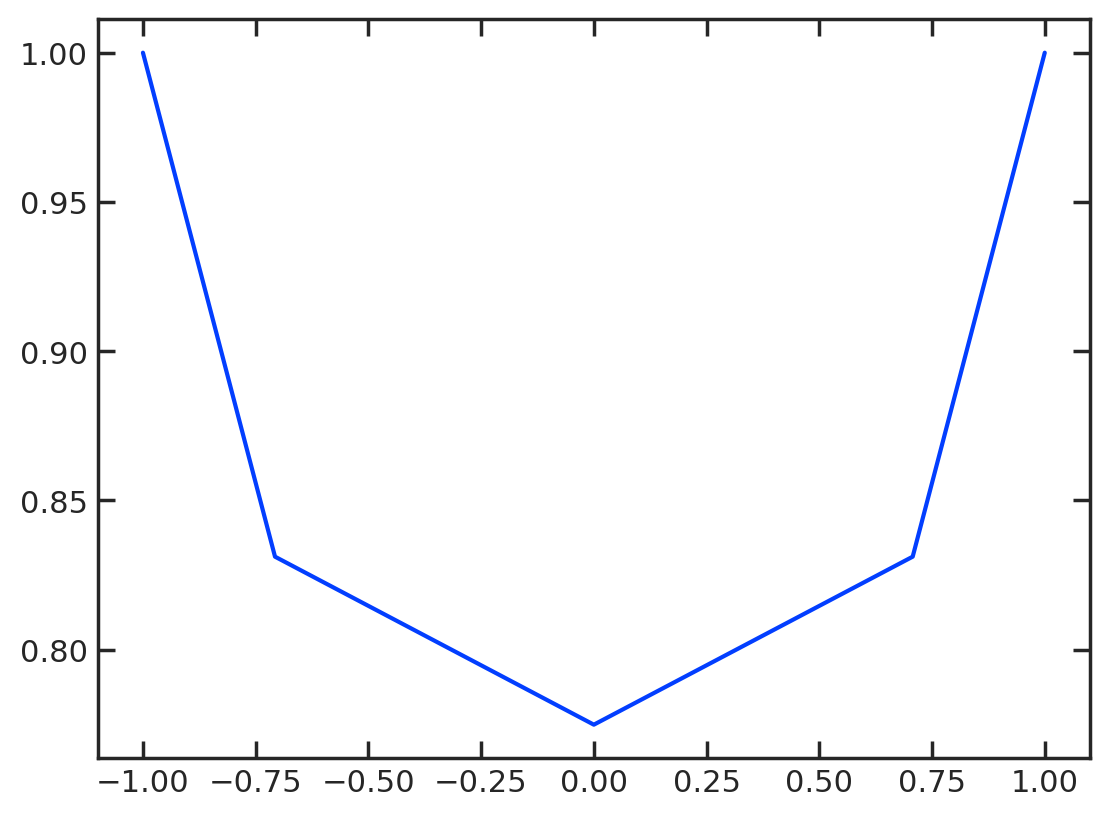

In [10]:
plt.plot(x, u)

In [6]:
u

array([1.        , 0.83116883, 0.77489177, 0.83116883, 1.        ])

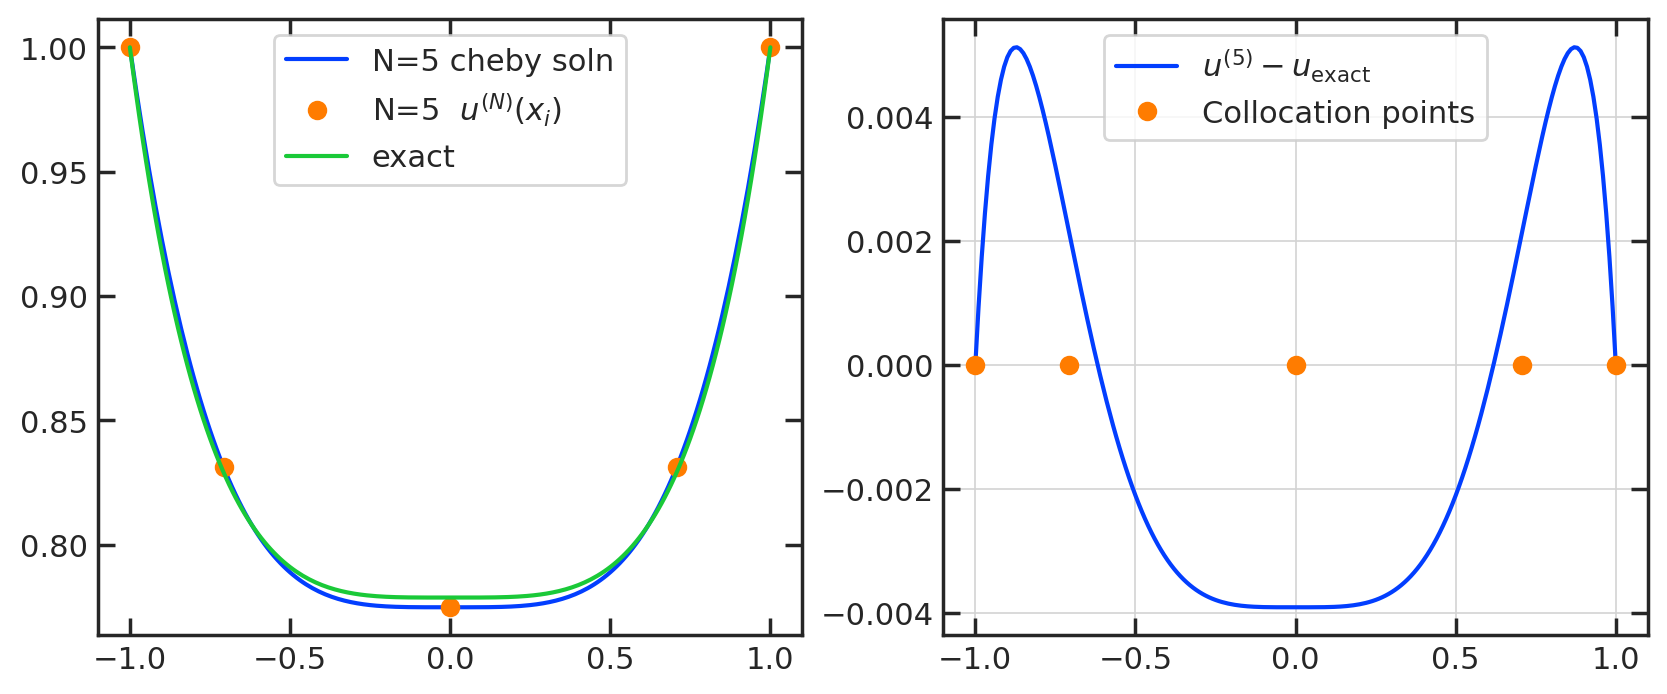

In [7]:
# make the solution look better, by evaluating more points
x_fine = np.linspace(-1, 1, num=201)
u_fine = ChebyshevInterpolate(u, ToSpec, x_fine)  # ==== HIGHLIGHT ====

fig, axs = plt.subplots(1, 2, figsize=(10, 4))
axs[0].plot(x_fine, u_fine, label="N=5 cheby soln")
axs[0].plot(x, u, "o", label="N=5  $u^{(N)}(x_i)$")

u_exact = np.exp((x_fine**4 - 1) / 4)
axs[0].plot(x_fine, u_exact, label="exact")


# difference in right panel
axs[1].plot(x_fine, u_fine - u_exact, label=r"$u^{(5)}-u_{\rm exact}$")
axs[1].plot(x, 0*x, 'o', label='Collocation points')

axs[0].legend()
axs[1].legend()
axs[1].grid()

In [7]:
x

array([-1.00000000e+00, -7.07106781e-01, -6.12323400e-17,  7.07106781e-01,
        1.00000000e+00])

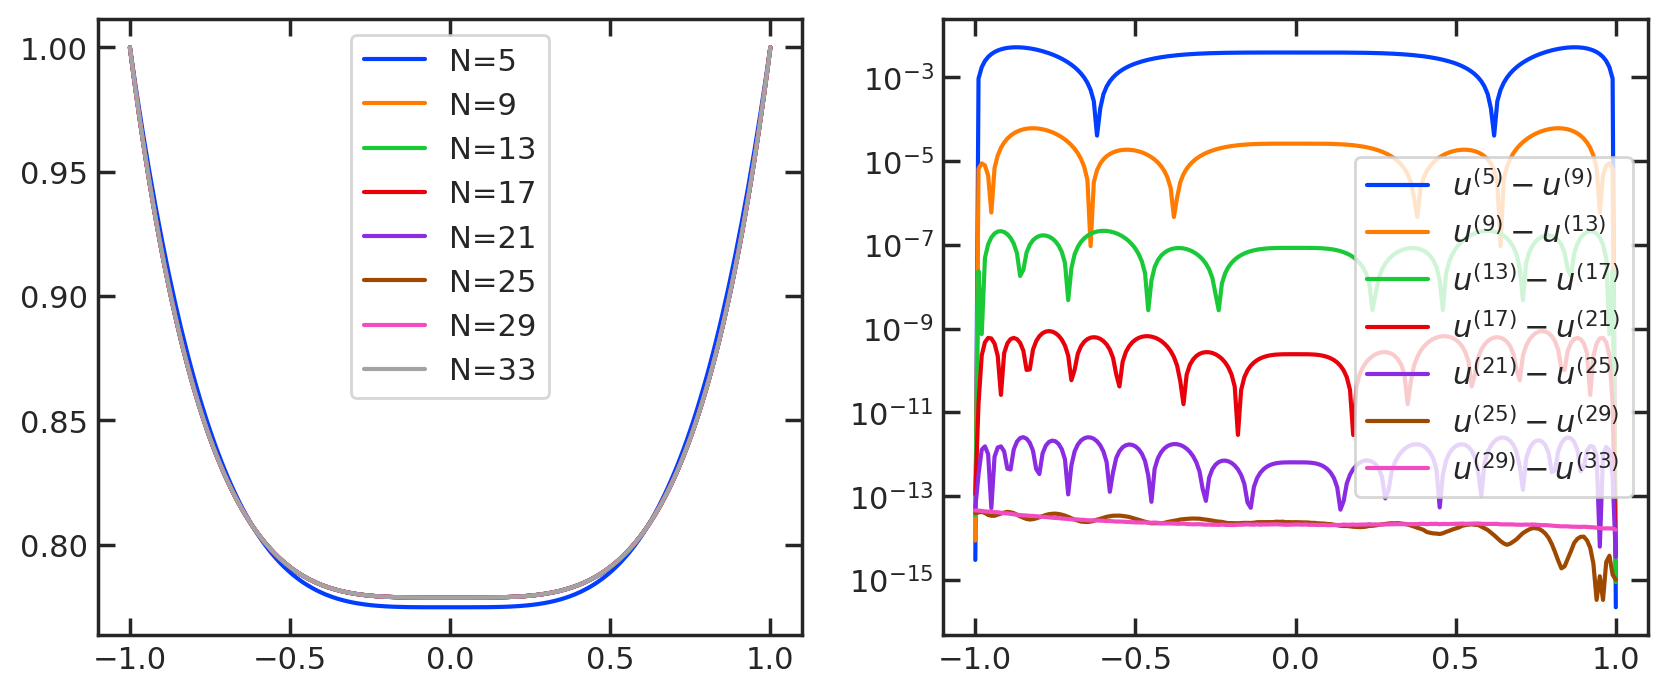

In [11]:
# DO BETTER -- INCREASE N

fig, axs = plt.subplots(1, 2, figsize=(10, 4))
x_fine = np.linspace(-1, 1, num=201)

u_fine_last = None
for N in 5, 9, 13, 17, 21, 25, 29, 33:
    x, ToSpec, ToPhys, D1, D2 = Chebyshev.ChebyshevHelpers(N)

    A = D2.copy()
    for i in range(N):
        A[i, i] -= x[i] ** 6 + 3 * x[i] ** 2
    # boundary conditions
    A[0, :] = 0
    A[0, 0] = 1
    A[-1, :] = 0
    A[-1, -1] = 1
    # right hand side
    b = np.zeros(N)
    b[0] = 1
    b[-1] = 1.0
    u = np.linalg.inv(A) @ b

    u_fine = ChebyshevInterpolate(u, ToSpec, x_fine)
    axs[0].plot(x_fine, u_fine, label=f"N={N}")

    if not u_fine_last is None:
        axs[1].plot(
            x_fine,
            np.abs(u_fine_last - u_fine),
            label=f"$u^{{({N_last})}} - u^{{({N})}}$",
        )
    u_fine_last = u_fine.copy()
    N_last = N

axs[0].legend()
axs[1].legend()
axs[1].set_yscale("log")